In [50]:
# import Libraries 
import pandas as pd
import matplotlib.pyplot as plt 

# import data 
df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df.info()

# Our job is to see the damande on jobs in usa through the year 

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [51]:
# We need :Usa data , Months as Str , count of job short title 

# US data
df_usa = df [ df['job_country']=="United States"]

In [52]:
# Months as str
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.strftime('%B')

In [53]:
# Pivot Table
df_usa_pivot =df_usa.pivot_table (
    index = 'job_posted_month' , 
    columns= 'job_title_short' ,
    aggfunc= 'size'
)

df_usa_pivot # The sort of the months are not correct 

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112
August,903,39,6634,3269,6318,68,1186,903,1515,194
December,648,40,3979,2641,3472,119,601,689,752,212
February,447,24,6124,3060,4956,56,1258,878,1127,90
January,527,36,8494,2655,6915,60,1544,773,1552,114
July,581,39,5201,2570,4876,65,883,747,1095,153
June,446,32,5683,2893,4645,48,1009,812,1033,93
March,438,19,6218,3183,4779,59,1114,829,1150,115
May,279,20,4993,2976,4377,49,839,746,914,90


In [54]:
# We want just the top 4
top_4 = df_usa['job_title_short'].value_counts().head(4)
top_4 = top_4.index.tolist()
top_4

df_usa_pivot = df_usa_pivot[top_4]

In [55]:
# Lets correct the sort of the months 

df_usa_pivot.reset_index(inplace=True) # we remove the months as the main index 

In [56]:
# To extract the months of each month , you must tranfer the type of the months into datetime 
df_usa_pivot['month_no'] = pd.to_datetime (df_usa_pivot['job_posted_month'], format='%B').dt.month

In [57]:
# Orginise the index by month_no column 
df_usa_pivot.set_index('month_no' , inplace=True)
df_usa_pivot.sort_index(inplace=True)

In [ ]:
# Remake the "job_postd_month" as the main index again 
df_usa_pivot.set_index('job_posted_month')

job_title_short,Data Analyst,Data Scientist,Data Engineer,Senior Data Scientist
job_posted_month,,,,
January,8494,6915,2655,1552
February,6124,4956,3060,1127
March,6218,4779,3183,1150
April,6049,4867,2801,991
May,4993,4377,2976,914
June,5683,4645,2893,1033
July,5201,4876,2570,1095
August,6634,6318,3269,1515
September,4639,4568,3224,1014


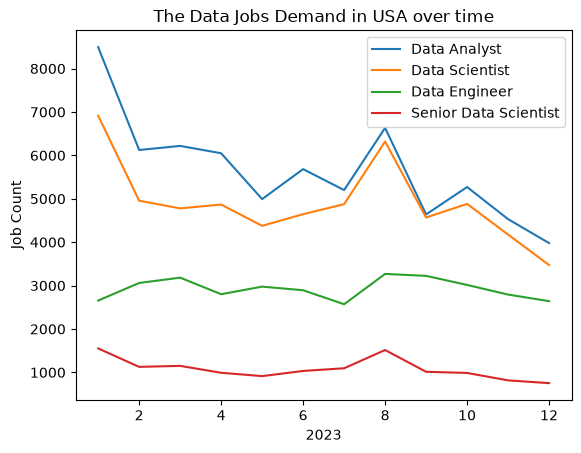

In [62]:
# Let's make the chart 

df_usa_pivot.plot (kind='line')
plt.title("The Data Jobs Demand in USA over time")
plt.xlabel ('2023')
plt.ylabel ("Job Count")
plt.legend()
plt.show()

In [ ]:
# VERY GOOOD !!!!